In [202]:
import csv
import numpy as np 
import tensorflow as tf 
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

In [203]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

In [204]:
NUM_CLASSES = 36

In [205]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [206]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

In [208]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [209]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_24 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 36)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466 (5.73 KB)

 Trainable params: 1,466 (5.73 KB)

 Non-trainable params: 0 (0.00 B)

In [210]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [211]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [212]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
 1/22 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.0391 - loss: 3.6080
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0185 - loss: 3.6019 - val_accuracy: 0.0056 - val_loss: 3.5505
Epoch 2/1000
 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0625 - loss: 3.5645
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0393 - loss: 3.5520 - val_accuracy: 0.0611 - val_loss: 3.5174
Epoch 3/1000
 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0391 - loss: 3.5566
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0448 - loss: 3.5218 - val_accuracy: 0.0822 - val_loss: 3.4751
Epoch 4/1000
 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0156 - loss: 3.5249
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.keras


In [213]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8711 - loss: 0.6189


In [214]:
model = tf.keras.models.load_model(model_save_path)

In [215]:
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[1.2215440e-03 1.4188954e-05 1.0076425e-09 9.2139118e-04 3.0392619e-02
 5.6818722e-06 8.0505345e-07 8.8938092e-09 1.1051201e-05 4.3541542e-03
 2.1552895e-08 1.4358022e-10 4.4173077e-01 4.1110510e-01 3.2885838e-10
 2.9582256e-10 3.1104616e-08 5.5402653e-14 2.8307404e-02 4.6193317e-02
 9.6725735e-12 1.9933275e-07 3.1564491e-09 2.3791415e-03 3.9736700e-04
 1.6054419e-04 5.6175429e-07 1.5185760e-10 2.3808464e-12 5.2805373e-12
 2.6862927e-02 1.2997199e-04 2.7040856e-05 1.0760778e-03 1.1511081e-04
 4.5929356e-03]
12


Confusion Matrix

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step


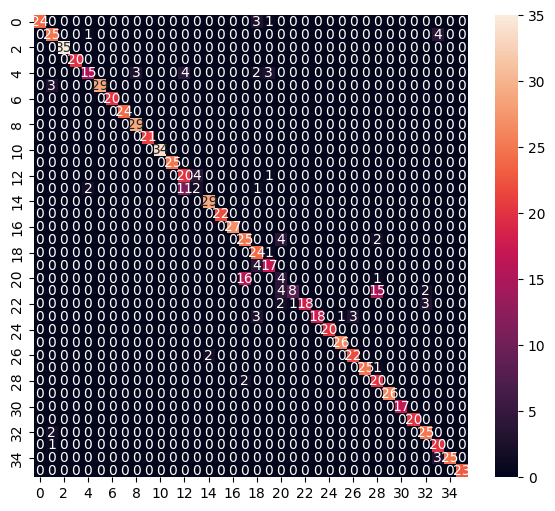

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.86      0.92        28
           1       0.81      0.83      0.82        30
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        20
           4       0.83      0.56      0.67        27
           5       1.00      0.91      0.95        32
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        24
           8       0.91      1.00      0.95        29
           9       1.00      1.00      1.00        21
          10       1.00      1.00      1.00        34
          11       1.00      1.00      1.00        25
          12       0.57      0.80      0.67        25
          13       0.33      0.12      0.18        16
          14       0.94      1.00      0.97        29
          15       1.00      1.00      1.00        22
          16       1.00      1.00      1.00        27
     

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
    
    fig,ax = plt.subplots(figsize=(7,6))
    sns.heatmap(df_cmx, annot=True, fmt='g', square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
Y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, Y_pred)
    
        

In [217]:
model.save(model_save_path, include_optimizer=False)

In [218]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/8s/d_xwgmds33z5snp5gk7x7m240000gn/T/tmp972eype0/assets


INFO:tensorflow:Assets written to: /var/folders/8s/d_xwgmds33z5snp5gk7x7m240000gn/T/tmp972eype0/assets


Saved artifact at '/var/folders/8s/d_xwgmds33z5snp5gk7x7m240000gn/T/tmp972eype0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_12')
Output Type:
  TensorSpec(shape=(None, 36), dtype=tf.float32, name=None)
Captures:
  14422783984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13412908576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12996399824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13491826608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13529537648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13382494064: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1764035802.512027 53669271 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1764035802.512039 53669271 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


7996

In [219]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

/Users/jorgerangel/Documents/dev/realtime-sign-language-translator /gesture-env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [220]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [221]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [222]:
%%time
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 50 μs, sys: 17 μs, total: 67 μs
Wall time: 71 μs


In [223]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.2215455e-03 1.4188946e-05 1.0076429e-09 9.2139159e-04 3.0392623e-02
 5.6818740e-06 8.0505527e-07 8.8938297e-09 1.1051206e-05 4.3541617e-03
 2.1552905e-08 1.4358054e-10 4.4173092e-01 4.1110492e-01 3.2885916e-10
 2.9582325e-10 3.1104626e-08 5.5402673e-14 2.8307414e-02 4.6193335e-02
 9.6725770e-12 1.9933282e-07 3.1564382e-09 2.3791424e-03 3.9736787e-04
 1.6054441e-04 5.6175503e-07 1.5185765e-10 2.3808429e-12 5.2805494e-12
 2.6862927e-02 1.2997205e-04 2.7040813e-05 1.0760770e-03 1.1511097e-04
 4.5929374e-03]
12
